In [ ]:
# Загружаем данные
import pandas as pd

train_df = pd.read_parquet('data/raw/train.parquet')
benchmark_queries_df = pd.read_parquet('data/raw/benchmark_queries.parquet')
benchmark_items_df = pd.read_parquet('data/raw/benchmark_items.parquet')

In [33]:
print("РАЗМЕРЫ ДАННЫХ\n")

print(f"train.parquet: {train_df.shape[0]} строк, {train_df.shape[1]} колонок")
print(f"benchmark_queries.parquet: {benchmark_queries_df.shape[0]} строк, {benchmark_queries_df.shape[1]} колонок")
print(f"benchmark_items.parquet: {benchmark_items_df.shape[0]} строк, {benchmark_items_df.shape[1]} колонок")

РАЗМЕРЫ ДАННЫХ

train.parquet: 497673 строк, 19 колонок
benchmark_queries.parquet: 2452 строк, 6 колонок
benchmark_items.parquet: 189212 строк, 14 колонок


In [34]:
print("ПРОПУСКИ В ДАННЫХ")

print("\nTrain:")
print(train_df.isnull().sum())

print("\nBenchmark Queries:")
print(benchmark_queries_df.isnull().sum())

print("\nBenchmark Items:")
print(benchmark_items_df.isnull().sum())

ПРОПУСКИ В ДАННЫХ

Train:
search_query                     0
search_location_id               0
search_is_delivery_search        0
search_infm_params_text          0
search_category                  0
item_title_raw                   0
item_rating_reviews_count    19211
item_rating                  28232
item_price                       0
item_microcat_id                 0
item_longitude                   4
item_location_id                 0
item_latitude                    4
item_is_phone_hidden             0
item_is_message_forbidden        0
item_infm_params_text            0
item_id                          0
item_description_raw             0
item_category_id                 0
dtype: int64

Benchmark Queries:
query_id                     0
search_query                 0
search_location_id           0
search_is_delivery_search    0
search_infm_params_text      0
search_category              0
dtype: int64

Benchmark Items:
item_title_raw                   0
item_rating_reviews_coun

In [3]:
# Несколько примеров запрос-объявление для общего понимания формата
print("ПРИМЕРЫ ИЗ TRAIN\n")

for idx in range(3):
    print(f"\n--- Пример {idx+1} ---")
    row = train_df.iloc[idx]
    print(f"Поисковый запрос: {row['search_query']}")
    print(f"Фильтры поиска: {row['search_infm_params_text']}")
    print(f"Заголовок объявления: {row['item_title_raw']}")
    print(f"Описание: {row['item_description_raw'][:100]}...")
    print(f"Категория поиска: {row['search_category']}")
    print(f"Категория объявления: {row['item_category_id']}")
    print("-" * 40)

ПРИМЕРЫ ИЗ TRAIN


--- Пример 1 ---
Поисковый запрос: скупка телевизоров
Фильтры поиска: 
Заголовок объявления: Скупка б/у техники
Описание: Скупаю практически любую современную новую и б/у технику(обязательно рабочую), до 80% от рыночной ст...
Категория поиска: 114
Категория объявления: 114
----------------------------------------

--- Пример 2 ---
Поисковый запрос: автоподбор
Фильтры поиска: Рейтинг пользователя 4 звезды и выше
Заголовок объявления: Автоподбор Разовый осмотр автомобиля
Описание: 🚗 Автоподбор и выездная диагностика автомобиля в Нижнем Новгороде и области.

🫴 Помогу подобрать опт...
Категория поиска: 114
Категория объявления: 114
----------------------------------------

--- Пример 3 ---
Поисковый запрос: баня на дровах
Фильтры поиска: Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье
Заголовок объявления: Баня на дровах "Прованс" на Цветочной
Описание: В  ритме современной жизни так сложно найти момент, чтобы остановиться: выключить телефон, отл

In [4]:
# Кол-во уникальных запросов
unique_queries = train_df['search_query'].nunique()
print(f"Уникальных запросов в train: {unique_queries}")

# Кол-во пар запрос-объявление
total_rows = len(train_df)
print(f"Всего строк в train: {total_rows}")

# Среднее число объявлений на запрос
avg_items = train_df.groupby('search_query')['item_id'].count()
print(f"\nСтатистика числа объявлений на запрос:")
print(f"  Среднее: {avg_items.mean():.2f}")
print(f"  Медиана: {avg_items.median():.2f}")
print(f"  Мин: {avg_items.min()}")
print(f"  Макс: {avg_items.max()}")

Уникальных запросов в train: 74529
Всего строк в train: 497673

Статистика числа объявлений на запрос:
  Среднее: 6.68
  Медиана: 1.00
  Мин: 1
  Макс: 6540


Топ-20 самых частых запросов:
search_query
маникюр                    6540
массаж                     5702
наращивание ресниц         5395
установка кондиционеров    4573
педикюр                    3436
сантехник                  3405
вывоз мусора               3278
эвакуатор                  3263
электрик                   3158
автоэлектрик               2790
покос травы                2477
вспашка земли              2315
манипулятор                2120
грузоперевозки газель      2034
натяжные потолки           2004
наращивание ногтей         1902
торты на заказ             1682
тонировка                  1644
поклейка обоев             1611
грузчики                   1540
Name: count, dtype: int64


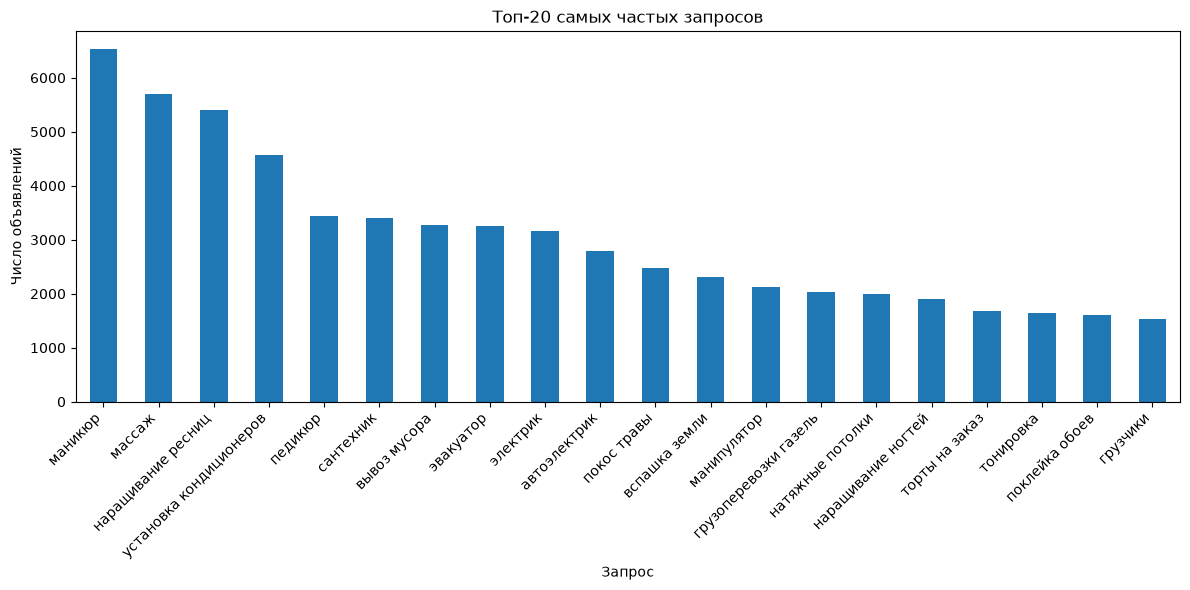

In [5]:
# Топ-20 самых частых запросов
top_queries = train_df['search_query'].value_counts().head(20)
print("Топ-20 самых частых запросов:")
print(top_queries)

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top_queries.plot(kind='bar')
plt.title('Топ-20 самых частых запросов')
plt.xlabel('Запрос')
plt.ylabel('Число объявлений')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Кол-во уникальных объявлений в train
unique_items = train_df['item_id'].nunique()
print(f"Уникальных объявлений в train: {unique_items}")

# Самые частые объявления
item_freq = train_df[['item_id', 'item_title_raw']].value_counts()
print(f"\nСтатистика частоты объявлений:")
print(f"  Среднее: {item_freq.mean():.2f}")
print(f"  Медиана: {item_freq.median():.2f}")
print(f"  Макс: {item_freq.max()}")

print(f"\nТоп-10 самых популярных объявлений:")
print(item_freq.head(10))

Уникальных объявлений в train: 344825

Статистика частоты объявлений:
  Среднее: 1.44
  Медиана: 1.00
  Макс: 188

Топ-10 самых популярных объявлений:
item_id           item_title_raw                                   
5d26f0c3faecce23  Бухгалтерские услуги для ИП и ООО / Бухгалтер УСН    188
391037f10a20ee24  Увеличение губ,Фулл Фэйс,м.Комендантский и Озерки    173
4be48741454a11dc  Остекление лоджии и балконов - ремонт под ключ       128
196d654750fa4944  Остекление лоджий по ключ в СПБ/ подарки             123
198eb6ac3f0dce86  Интерьерная и архитектурная съемка                    95
8e223b1181386346  Предметная съемка для бизнеса и брендов               94
ad0b5c32404b1471  Деловая и корпоративная фотосъемка в Казани           91
dd76c4742f5eedbc  Уничтожение клопов тараканов грызунов Дезинфекция     79
6075f787fa6453ba  Дизайнер интерьера. Дизайн проект под ключ 3D         77
be94ed17c23c5ed2  Вскрытие замков Дверей Автомобилей Замена Ремонт      75
Name: count, dtype: int64


In [13]:
insights = """
КЛЮЧЕВЫЕ ИНСАЙТЫ ПОСЛЕ EDA:

   - Уникальных запросов в train: {unique_queries}
   - Уникальных объявлений в train: {unique_items}
   - Среднее число объявлений на запрос: {avg_items:.2f}
"""

print(insights.format(
    unique_queries=unique_queries,
    unique_items=unique_items,
    avg_items=avg_items.mean(),
))


КЛЮЧЕВЫЕ ИНСАЙТЫ ПОСЛЕ EDA:

   - Уникальных запросов в train: 74529
   - Уникальных объявлений в train: 344825
   - Среднее число объявлений на запрос: 6.68

